# Primeiros Passos em EDA: estatísticas, gráficos e correlações


In [1]:
import os
import sys
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# Reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Opções de display
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# Diretórios para salvar artefatos (test set e figuras)
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Versões — pandas: {pd.__version__}, numpy: {np.__version__}")
print("Diretório de artefatos:", ARTIFACTS_DIR.resolve())

Versões — pandas: 2.3.2, numpy: 2.3.2
Diretório de artefatos: C:\Users\Everton\Documents\IFSP\CMPINAM\1-Aulas\notebooks\artifacts



## 1) Dataset - California Housing (scikit-learn)

O **California Housing Dataset** foi construído a partir dos dados do censo de 1990 nos Estados Unidos.  
Cada linha representa uma região geográfica (célula de *block group*) na Califórnia, e o alvo (`target`) é o **valor mediano das casas** naquela região (em centenas de milhares de dólares).

**Atributos:**
- `MedInc`: renda mediana dos habitantes da região (em dezenas de milhares de dólares).  
- `HouseAge`: idade mediana das construções.  
- `AveRooms`: número médio de cômodos por domicílio.  
- `AveBedrms`: número médio de quartos por domicílio.  
- `Population`: população total da região.  
- `AveOccup`: número médio de moradores por domicílio.  
- `Latitude`: latitude da região.  
- `Longitude`: longitude da região.  
- `target` (MedHouseVal): valor mediano das casas (em centenas de milhares de dólares).

**Fonte:** derivado do censo americano de 1990, disponibilizado no *StatLib repository* e incorporado ao scikit-learn.



In [2]:
from sklearn.datasets import fetch_california_housing

def load_sklearn_california(as_frame=True):
    """
    Tenta carregar o dataset California Housing via scikit-learn.
    Retorna um DataFrame 'df' com as colunas de features + 'target'.
    """
    data = fetch_california_housing(as_frame=as_frame)
    df = data.frame.copy()
    df.rename(columns={"MedHouseVal": "target"}, inplace=True)
    return df

df = None
try:
    df = load_sklearn_california(as_frame=True)
    source = "sklearn"
    print("Dataset carregado via scikit-learn (fetch_california_housing).")
except Exception as e:
    print("⚠️ Falha ao carregar via scikit-learn:", e)

Dataset carregado via scikit-learn (fetch_california_housing).


In [3]:
# %%
assert df is not None, (
    "Não foi possível carregar dados.\n"
    "- Opção A: tente novamente com internet habilitada para o scikit-learn baixar o California Housing.\n"
)
print("Formato:", df.shape)
print("Colunas:", list(df.columns))
df.head()

Formato: (20640, 9)
Colunas: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'target']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2) Split (treino/teste) 80/20
Antes de qualquer exploração mais profunda, separe um **conjunto de teste** (20%) e **congele-o**.  
Isso garante que teremos dados “novos” para avaliar o modelo no final do projeto.

In [5]:
# %%
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)

print("Treino:", train_set.shape, " | Teste:", test_set.shape)

# Congelar o test set em disco para evitar olhar para ele durante a EDA
test_path = Path("artifacts") / "test_set.csv"
test_set.to_csv(test_path, index=False)
print("Conjunto de teste salvo em:", test_path.resolve())

# Usaremos apenas o train_set a partir de agora
train = train_set.copy()

Treino: (16512, 9)  | Teste: (4128, 9)
Conjunto de teste salvo em: C:\Users\Everton\Documents\IFSP\CMPINAM\1-Aulas\notebooks\artifacts\test_set.csv



> **Importante:** A partir daqui, **trabalhe apenas com `train_set`**. O `test_set` ficou salvo para uso **somente no final**.



## 3) Visão rápida do *train set*
- Dimensões, tipos e valores ausentes  
- Estatística descritiva essencial


In [6]:
train = train_set.copy()
print(train.shape)
display(train.head())

print("\nTipos:")
display(train.dtypes)

print("\nValores ausentes por coluna:")
display(train.isna().sum())

print("\nEstatística descritiva:")
display(train.describe().T)

(16512, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03,1.030
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16,3.821
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48,1.726
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11,0.934
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80,0.965



Tipos:


MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
target        float64
dtype: object


Valores ausentes por coluna:


MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64


Estatística descritiva:


,count,mean,std,min,25%,50%,75%,max
MedInc,16512.0,3.880754,1.904294,0.499900,2.566700,3.545800,4.773175,15.000100
HouseAge,16512.0,28.608285,12.602499,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,16512.0,5.435235,2.387375,0.888889,4.452055,5.235874,6.061037,141.909091
AveBedrms,16512.0,1.096685,0.433215,0.333333,1.006508,1.049286,1.100348,25.636364
Population,16512.0,1426.453004,1137.056380,3.000000,789.000000,1167.000000,1726.000000,35682.000000
AveOccup,16512.0,3.096961,11.578744,0.692308,2.428799,2.817240,3.280000,1243.333333
Latitude,16512.0,35.643149,2.136665,32.550000,33.930000,34.260000,37.720000,41.950000
Longitude,16512.0,-119.582290,2.005654,-124.350000,-121.810000,-118.510000,-118.010000,-114.310000
target,16512.0,2.071947,1.156226,0.149990,1.198000,1.798500,2.651250,5.000010


## 4) Mapas e dispersões
Vamos visualizar a distribuição espacial das amostras e do alvo (`target`) usando **Longitude × Latitude**.

- **Mapa de densidade**: `alpha=0.1` destaca regiões com mais pontos.  
- **Mapa de valores**: cor = `target`, tamanho do ponto proporcional à população.


In [28]:
def scatter_geo(df, title="Mapa (Longitude × Latitude)", alpha=0.1, figsize=(8,6)):
    assert {"Longitude","Latitude"}.issubset(df.columns), "Colunas 'Longitude' e 'Latitude' não encontradas."
    ax = df.plot(kind="scatter", x="Longitude", y="Latitude", alpha=alpha, figsize=figsize)
    ax.set_title(title)
    ax.grid(True)

def scatter_price_map(df, title="Mapa de valores (cor=target, tamanho=Population)", figsize=(9,7)):
    assert {"Longitude","Latitude","target"}.issubset(df.columns), "Faltam colunas para o mapa de valor."
    size_col = "Population" if "Population" in df.columns else None
    s = df[size_col] / df[size_col].max() * 50 + 10 if size_col else 10  # tamanho relativo
    ax = df.plot(kind="scatter", x="Longitude", y="Latitude", alpha=0.4,
                 c="target", cmap="jet", colorbar=True, s=s, figsize=figsize)
    ax.set_title(title)
    ax.grid(True)

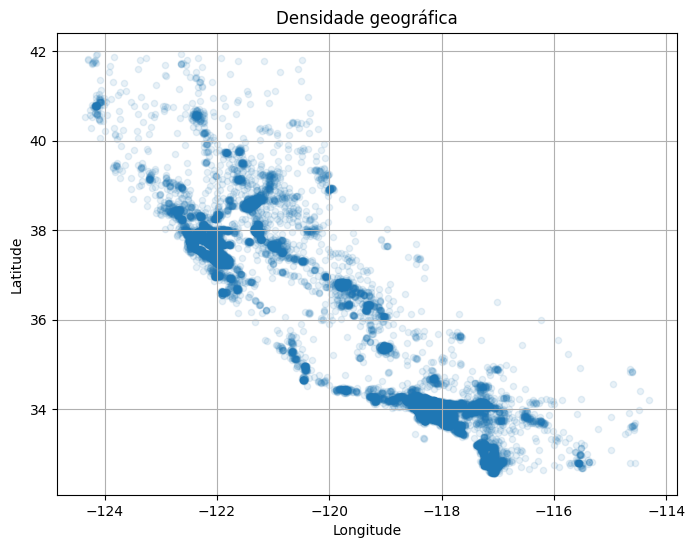

In [29]:
scatter_geo(train, title="Densidade geográfica")
plt.show()

### Interpretação do gráfico — Densidade geográfica

O gráfico mostra a **distribuição espacial dos dados** do dataset California Housing, com cada ponto representando uma região geográfica (block group) da Califórnia.

- O eixo **Longitude** (horizontal) e o eixo **Latitude** (vertical) permitem visualizar a localização real dos dados.  
- As áreas com **maior concentração de pontos** (mais escuros) indicam regiões **mais densamente povoadas**.  
- Observa-se nitidamente:
  - A concentração de pontos na região de **Los Angeles** (sul da Califórnia).  
  - Outra grande concentração na **Baía de São Francisco** (centro-oeste da Califórnia).  
  - Algumas distribuições menores em torno de cidades no interior.  

Esse tipo de gráfico ajuda a entender **onde estão as populações mais densas** e serve como base para investigar como a localização influencia o valor das casas.

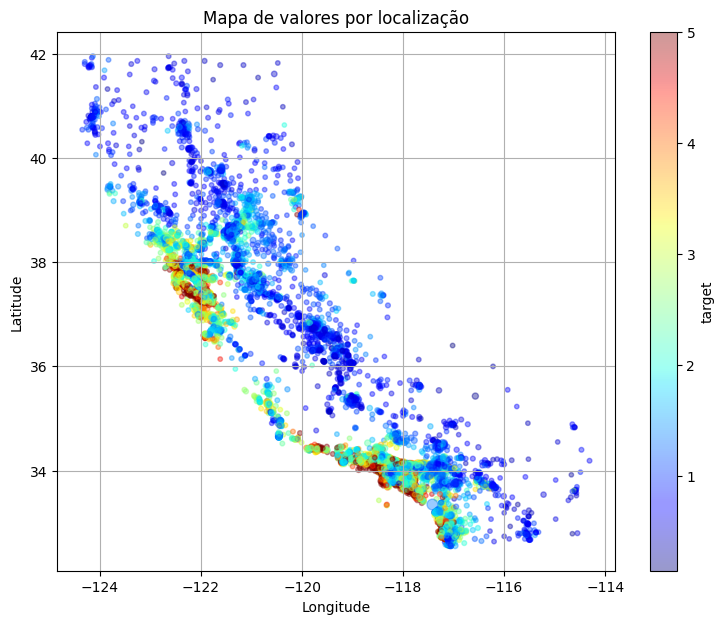

In [30]:
scatter_price_map(train, title="Mapa de valores por localização")
plt.show()

### Interpretação do gráfico — Mapa de valores por localização

Este gráfico mostra os pontos geográficos da Califórnia com duas camadas de informação:

- **Cor dos pontos (escala de cores):** representa o valor mediano das casas (`target`).  
  - Tons **avermelhados** → casas com valores mais altos.  
  - Tons **azulados** → casas com valores mais baixos.  
- **Tamanho dos pontos:** proporcional à população da região.  

**Principais observações:**
- Regiões costeiras próximas a **Los Angeles** e **Baía de São Francisco** apresentam casas com valores significativamente mais altos (mais pontos vermelhos).  
- Áreas mais afastadas do litoral tendem a concentrar valores mais baixos (pontos azuis).  
- A população também é mais densa nesses centros urbanos, reforçando a relação entre localização, densidade e valor dos imóveis.  

Esse gráfico reforça a ideia de que **localização é um fator crítico** para explicar o valor das casas no dataset.

## 5) Correlações e pares promissores
- Matriz de correlação (`df.corr()`): procure variáveis mais associadas ao `target` (positiva ou negativamente).  
- **Top-5** correlações com o alvo (em valor absoluto).  
- Pares promissores (ex.: `MedInc × target`), com *scatter* e linha de tendência simples.


In [36]:
# Matriz de correlação (apenas colunas numéricas)
corr_matrix = train.corr(numeric_only=True)

# exibir com 3 casas decimais
display(corr_matrix.style.background_gradient(cmap="coolwarm").format(precision=3))

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
MedInc,1.000,-0.122,0.336,-0.073,0.004,0.022,-0.077,-0.017,0.691
HouseAge,-0.122,1.000,-0.161,-0.088,-0.292,0.016,0.005,-0.102,0.104
AveRooms,0.336,-0.161,1.000,0.836,-0.074,-0.005,0.111,-0.029,0.158
AveBedrms,-0.073,-0.088,0.836,1.000,-0.071,-0.006,0.073,0.017,-0.051
Population,0.004,-0.292,-0.074,-0.071,1.000,0.072,-0.102,0.094,-0.026
AveOccup,0.022,0.016,-0.005,-0.006,0.072,1.000,0.006,-0.001,-0.022
Latitude,-0.077,0.005,0.111,0.073,-0.102,0.006,1.000,-0.924,-0.143
Longitude,-0.017,-0.102,-0.029,0.017,0.094,-0.001,-0.924,1.000,-0.046
target,0.691,0.104,0.158,-0.051,-0.026,-0.022,-0.143,-0.046,1.000


In [38]:
# Top-5 atributos mais correlacionados com o alvo (valor absoluto)
target_corr = corr_matrix["target"].drop(labels=["target"]).abs().sort_values(ascending=False)
print("Top-5 correlações (|corr|) com target:")
display(target_corr.head(5))

# Dispersão e regressão simples para o atributo mais correlacionado
top_attr = target_corr.index[0]
print("\nAtributo mais correlacionado:", top_attr)

Top-5 correlações (|corr|) com target:


MedInc       0.690647
AveRooms     0.158485
Latitude     0.142983
HouseAge     0.103706
AveBedrms    0.051351
Name: target, dtype: float64


Atributo mais correlacionado: MedInc


### Interpretação da correlação Latitude × target

A correlação entre **Latitude** e o **valor mediano das casas (`target`)** é de aproximadamente **–0,143**.

- O sinal **negativo** indica que, conforme a latitude aumenta (ou seja, ao mover-se para o norte da Califórnia), os valores médios das casas tendem a diminuir.  
- A intensidade é **fraca** (–0,14 não é próximo de –1), mas revela uma tendência geral.  

**Contexto geográfico:**
- Latitudes **menores (~33–34)** correspondem ao **sul da Califórnia** (Los Angeles, San Diego), regiões com imóveis mais caros.  
- Latitudes **maiores (~37–38)** incluem o **norte da Califórnia**, onde há áreas urbanas caras (ex.: São Francisco), mas também muitas regiões do interior menos valorizadas.  
- Essa mistura puxa a correlação para baixo, mostrando que fora dos grandes centros costeiros os valores tendem a cair.  

👉 **Resumo:** a correlação negativa reflete que casas ao sul (latitudes menores) costumam ter valores mais altos, enquanto casas ao norte (latitudes maiores) em geral são menos valorizadas, salvo exceções como a Baía de São Francisco.

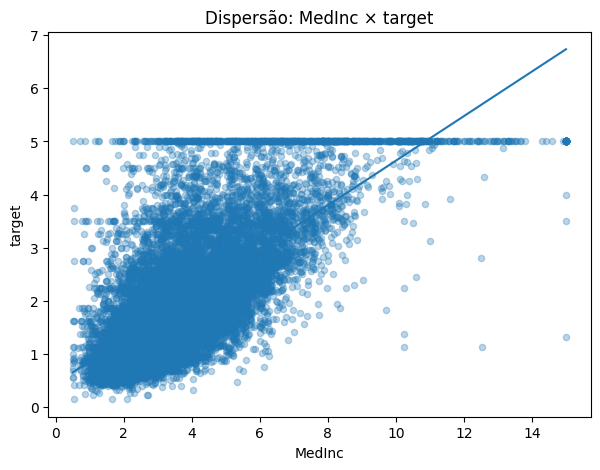

In [39]:
ax = train.plot(kind="scatter", x=top_attr, y="target", alpha=0.3, figsize=(7,5))
ax.set_title(f"Dispersão: {top_attr} × target")

# linha de tendência simples (OLS via numpy polyfit)
coef = np.polyfit(train[top_attr], train["target"], 1)
x_line = np.linspace(train[top_attr].min(), train[top_attr].max(), 100)
y_line = coef[0] * x_line + coef[1]
plt.plot(x_line, y_line)
plt.show()

### Interpretação do gráfico — Dispersão: MedInc × target

O gráfico mostra a relação entre a **renda mediana das famílias (`MedInc`)** e o **valor mediano das casas (`target`)**.

**Principais observações:**
- Existe uma **correlação positiva clara**: conforme a renda mediana aumenta, o valor das casas também tende a aumentar.  
- Para rendas baixas (`MedInc` entre 0 e 4), os valores de casas ficam concentrados em torno de 1–2 (100 a 200 mil dólares).  
- Para rendas mais altas (`MedInc` acima de 6), observa-se uma concentração maior de valores de casas entre 3–5 (300 a 500 mil dólares).  
- Há um **teto nos preços**: muitos pontos ficam presos no valor máximo de `target = 5.0`, pois o dataset foi **truncado em 500 mil dólares** no censo original.  
- Alguns pontos fora da curva sugerem **outliers** (renda muito alta, mas preço de casa não tão alto e vice-versa).

👉 **Resumo:** este gráfico evidencia que **renda é um forte preditor para o valor das casas**, embora o efeito do teto limite a análise nos valores mais altos.


## 6) Atributos derivados (engenharia leve)
Crie atributos simples que **façam sentido** e testaremos se melhoram a correlação com o alvo.

Sugestões (para o dataset do **sklearn**):
- `BedroomsPerRoom = AveBedrms / AveRooms`  
- `RoomsPerPerson = AveRooms / AveOccup`

In [41]:
train_fe = train.copy()

if {"AveBedrms","AveRooms"}.issubset(train_fe.columns):
    train_fe["BedroomsPerRoom"] = train_fe["AveBedrms"] / train_fe["AveRooms"]

if {"AveRooms","AveOccup"}.issubset(train_fe.columns):
    train_fe["RoomsPerPerson"] = train_fe["AveRooms"] / train_fe["AveOccup"]

print("Novas colunas criadas:", [c for c in train_fe.columns if c not in train.columns])

corr_fe = train_fe.corr(numeric_only=True)["target"].drop(labels=["target"]).abs().sort_values(ascending=False)
print("Top-8 |corr| com target após features derivadas:")
display(corr_fe.head(8))

Novas colunas criadas: ['BedroomsPerRoom', 'RoomsPerPerson']
Top-8 |corr| com target após features derivadas:


MedInc             0.690647
BedroomsPerRoom    0.257419
RoomsPerPerson     0.212915
AveRooms           0.158485
Latitude           0.142983
HouseAge           0.103706
AveBedrms          0.051351
Longitude          0.046349
Name: target, dtype: float64

## 7) Boxplot: distribuição e outliers

O **boxplot** é uma forma gráfica de representar a **distribuição de um conjunto de dados**.  

Ele mostra:
- **Mediana** (linha dentro da caixa).  
- **Quartis (Q1 e Q3):** limites inferior e superior da caixa, que contêm 50% dos dados.  
- **Extremos (whiskers):** valores próximos aos limites inferior e superior (sem serem outliers).  
- **Outliers:** pontos fora dos limites normais, destacados como bolinhas individuais.  

👉 Em resumo: o boxplot ajuda a visualizar **distribuição, simetria, dispersão e outliers** de uma variável.

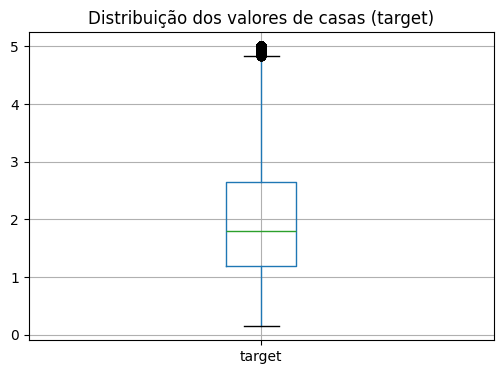

In [45]:
train.boxplot(column="target", figsize=(6,4))
plt.title("Distribuição dos valores de casas (target)")
plt.show()

O boxplot mostra a distribuição do atributo `target`, que representa o valor mediano das casas (em centenas de milhares de dólares).

**Interpretação:**
- A maior parte dos valores se concentra abaixo de 3 (300 mil USD).  
- A linha da mediana indica o valor típico no conjunto.  
- O gráfico revela um **teto em 5.0 (500 mil USD)**, causado pelo truncamento dos dados no censo original.  
- Alguns pontos acima ou abaixo da caixa podem ser considerados **outliers**, mas a principal característica é a forte concentração em valores médios e o corte superior.


### 8) Histograma

O **histograma** é um gráfico que mostra como os valores de uma variável se distribuem em diferentes **faixas (bins)**.

- O eixo **x** representa os intervalos de valores.  
- O eixo **y** mostra a frequência (quantas observações caem em cada intervalo).  
- Permite identificar se os dados estão concentrados em uma faixa, se seguem uma distribuição aproximadamente normal ou se apresentam assimetrias.  
- Útil para detectar **distribuições enviesadas** (skewness) ou presença de valores extremos.

👉 Em resumo: o histograma ajuda a visualizar a **forma da distribuição** de uma variável.


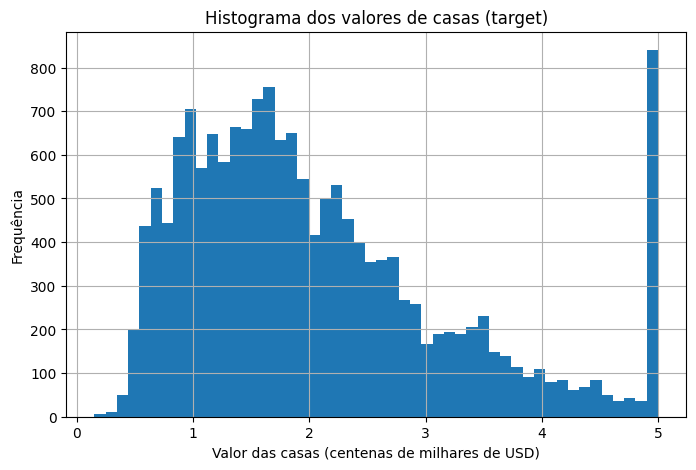

In [46]:
# Histograma da variável target
train["target"].hist(bins=50, figsize=(8,5))
plt.xlabel("Valor das casas (centenas de milhares de USD)")
plt.ylabel("Frequência")
plt.title("Histograma dos valores de casas (target)")
plt.show()

O histograma mostra a frequência dos valores medidos pelo atributo `target` (valor mediano das casas, em centenas de milhares de dólares).

**Interpretação:**
- A maior parte das casas tem valor abaixo de 3 (300 mil USD).  
- Existe uma cauda longa à direita (valores mais altos), mas cortada em 5 (500 mil USD), mostrando novamente o **teto** do dataset.  
- O histograma reforça a assimetria: mais casas baratas, poucas casas muito caras.

## 9) Gráfico de barras: valor médio das casas por faixas de idade

Neste exemplo, agrupamos o atributo `HouseAge` em faixas (0–10, 11–20, 21–30, 31–40, 41+) e calculamos o valor médio do `target` (preço das casas) em cada grupo.

Isso permite observar se a idade das casas tem relação com o valor dos imóveis.


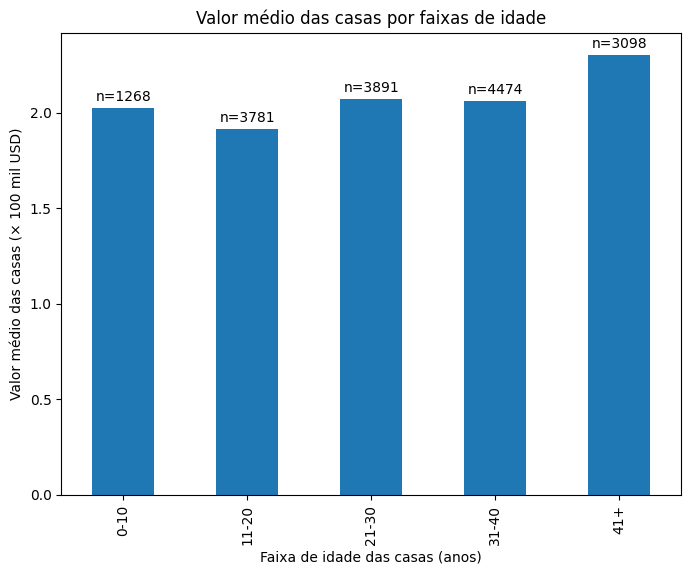

In [64]:
# Criar faixas de idade das casas
bins = [0, 10, 20, 30, 40, np.inf]
labels = ["0-10", "11-20", "21-30", "31-40", "41+"]

tmp = train.copy()
tmp["HouseAge_bin"] = pd.cut(tmp["HouseAge"], bins=bins, labels=labels, right=True)

# Calcular valor médio das casas por faixa de idade
grp = (
    tmp.groupby("HouseAge_bin", observed=True)
       .agg(media_target=("target", "mean"), n=("target", "size"))
       .reset_index()
)

# Gráfico de barras
ax = grp.plot(kind="bar", x="HouseAge_bin", y="media_target", legend=False, figsize=(8,6))
ax.set_title("Valor médio das casas por faixas de idade")
ax.set_xlabel("Faixa de idade das casas (anos)")
ax.set_ylabel("Valor médio das casas (× 100 mil USD)")

# Anotar contagem no topo das barras
for p, count in zip(ax.patches, grp["n"]):
    ax.annotate(f"n={count}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", xytext=(0, 3), textcoords="offset points")

plt.show()

### Interpretação — Valor médio por faixas de idade das casas

O gráfico mostra o valor médio das casas (`target`) para diferentes faixas de idade (`HouseAge`).

**Principais observações:**
- Casas **muito novas (0–10 anos)** têm valor médio um pouco acima de 2 (≈ 200 mil USD).  
- Casas na faixa de **11–20 anos** apresentam o menor valor médio (≈ 190 mil USD).  
- Entre **21–40 anos**, os valores sobem levemente, em torno de 210 mil USD.  
- Curiosamente, casas **mais antigas (41+ anos)** apresentam o **maior valor médio** (≈ 230 mil USD).

**Possível explicação:**
- Casas muito antigas podem estar em **regiões centrais ou costeiras mais valorizadas**, onde a localização compensa a idade.  
- O número de amostras em cada faixa é relativamente equilibrado (3k–4k), garantindo boa representatividade.  

👉 **Resumo:** não há uma relação linear simples entre idade e valor das casas. Pelo contrário, o preço médio tende a ser maior tanto para casas muito novas quanto para casas muito antigas, sugerindo que **a localização tem peso maior que a idade** na determinação do valor.

## 10) Tarefas — Atividade 2 (Moodle)

📌 Este notebook deve ser entregue no Moodle em:  
**Atividade 2 - Análise Exploratória de Dados (EDA)**

Realize as análises abaixo. Cada tarefa deve conter:
1. **Código em Python** para gerar o resultado.  
2. **Markdown explicativo** abaixo do código, comentando os gráficos ou valores obtidos.  

### Tarefa 1 — Estatísticas descritivas
- Gere estatísticas descritivas do `train` (`describe()`).
- Interprete em Markdown:  
  - Qual é o valor típico (mediana) das casas?  
  - Há atributos com grande dispersão (desvio padrão alto)?

---

In [66]:
## Código

#### Interpretação

Comente aqui

### Tarefa 2 — Histograma de `MedInc`
- Plote um histograma do atributo `MedInc` (renda mediana da região).  
- Em Markdown: explique a distribuição encontrada.  
  - As rendas estão concentradas em alguma faixa específica?  
  - Existem regiões com renda muito acima da média?  
  - Como isso pode impactar no valor das casas?

---


In [67]:
## Código

#### Interpretação

Comente aqui

### Tarefa 3 — Boxplot de um atributo
- Escolha um atributo numérico (ex.: `MedInc` ou `HouseAge`) e faça um boxplot.  
- Em Markdown: descreva a dispersão, presença de outliers e possíveis impactos na análise.

---

In [69]:
## Código

#### Interpretação

Comente aqui

### Tarefa 4 — Boxplot do target por faixas de idade das casas

1. Crie uma nova variável categórica que agrupe a idade das casas (`HouseAge`) em faixas, por exemplo:  
   - 0–10 anos  
   - 11–20 anos  
   - 21–30 anos  
   - 31–40 anos  
   - 41+ anos  

   (use `pd.cut()` para criar os intervalos).  

2. Plote um **boxplot** do `target` (valor das casas) para cada faixa de idade.  

3. Em Markdown: comente os resultados.  
   - Casas mais antigas tendem a valer mais ou menos?  
   - As distribuições são parecidas entre as faixas?  
   - Há outliers importantes em alguma faixa?

---

In [70]:
## Código

#### Interpretação

Comente aqui

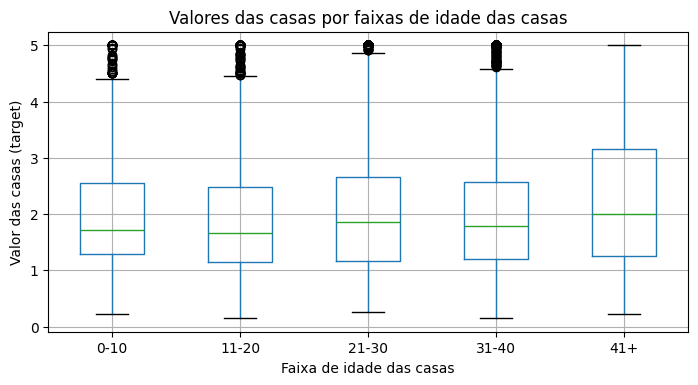

In [56]:
# Criar faixas de idade das casas
bins = [0, 10, 20, 30, 40, np.inf]
labels = ["0-10", "11-20", "21-30", "31-40", "41+"]

train["HouseAge_bin"] = pd.cut(train["HouseAge"], bins=bins, labels=labels, right=True)

# Boxplot do target por faixas de idade
train.boxplot(column="target", by="HouseAge_bin", figsize=(8,4))
plt.title("Valores das casas por faixas de idade das casas")
plt.suptitle("")  # remove título automático extra
plt.xlabel("Faixa de idade das casas")
plt.ylabel("Valor das casas (target)")
plt.show()

### Tarefa 5 — Dispersão entre Population e target

1. Faça um gráfico de dispersão entre `Population` (população da região) e `target` (valor das casas).  
2. Em Markdown: descreva a relação observada.  
   - Regiões mais populosas têm casas mais caras?  
   - Existe muita dispersão nos dados?  
   - Há evidências de **outliers** (regiões com população extremamente alta)?  

In [71]:
## Código

#### Interpretação

Comente aqui

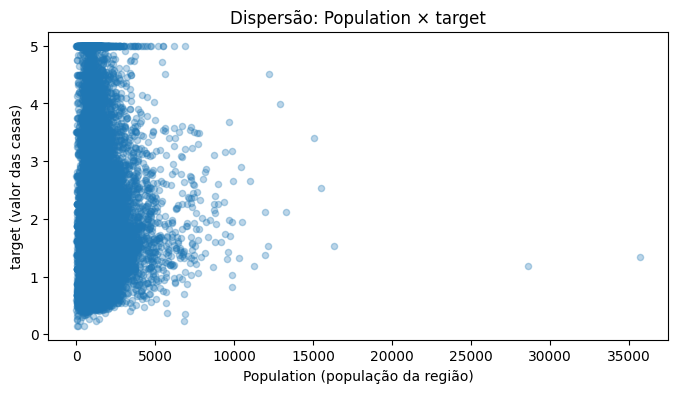

In [55]:
# Dispersão entre Population e target
train.plot(kind="scatter", x="Population", y="target", alpha=0.3, figsize=(8,4))
plt.title("Dispersão: Population × target")
plt.xlabel("Population (população da região)")
plt.ylabel("target (valor das casas)")
plt.show()

#### Interpretação do gráfico — Population × target

**1. Regiões mais populosas têm casas mais caras?**  
Não. Não há uma relação clara entre maior população e preços mais altos.  
A maioria dos pontos está concentrada em populações **abaixo de 5.000 habitantes**, com valores de casas que variam em toda a faixa do `target`.

**2. Existe muita dispersão nos dados?**  
Sim. Mesmo em populações baixas, o valor das casas varia bastante (de 0 até 5).  
Isso mostra que a **população sozinha não explica bem o valor das casas**.

**3. Há evidências de outliers?**  
Sim. Existem algumas regiões com população muito alta (10.000, 20.000, até 35.000), mas esses pontos não correspondem a casas mais caras.  
São casos isolados que não seguem uma tendência clara.

---

👉 **Resumo:** A população da região não é um preditor forte do preço das casas.  
Embora existam regiões muito populosas, os valores medianos das casas não aumentam proporcionalmente, reforçando que outros atributos (como renda) são mais relevantes.

### Tarefa 6 — Gráfico de barras: preço médio por faixas de renda

1) Crie faixas (bins) para `MedInc` (renda mediana).  
2) Calcule a **média de `target`** em cada faixa.  
3) Plote um **gráfico de barras** com o preço médio por faixa e anote a **contagem de amostras** por barra.  

Depois do código, escreva em Markdown:
- O preço médio **sobe** conforme a renda aumenta?  
- Alguma faixa tem **poucas amostras** (atenção à interpretação)?  
- Como esses resultados dialogam com o *scatter* `MedInc × target`?

In [73]:
## Código

#### Interpretação

Comente aqui

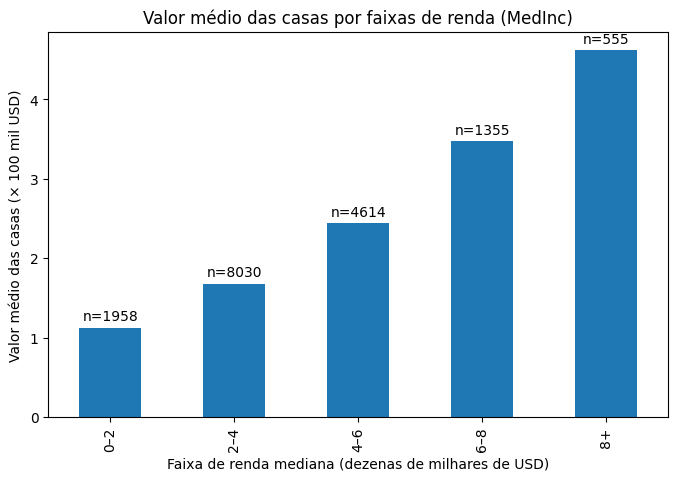

In [58]:
# Binning de renda (MedInc) e agregações
bins = [0, 2, 4, 6, 8, float("inf")]
labels = ["0–2", "2–4", "4–6", "6–8", "8+"]

tmp = train.copy()
tmp["MedInc_bin"] = pd.cut(tmp["MedInc"], bins=bins, labels=labels, right=True)

grp = (
    tmp.groupby("MedInc_bin", observed=True)
       .agg(media_target=("target", "mean"), n=("target", "size"))
       .reset_index()
)

# 1) Barras: preço médio por faixa de renda
ax = grp.plot(kind="bar", x="MedInc_bin", y="media_target", legend=False, figsize=(8,5))
ax.set_title("Valor médio das casas por faixas de renda (MedInc)")
ax.set_xlabel("Faixa de renda mediana (dezenas de milhares de USD)")
ax.set_ylabel("Valor médio das casas (× 100 mil USD)")

# Anotar contagem no topo das barras
for p, count in zip(ax.patches, grp["n"]):
    ax.annotate(f"n={count}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", xytext=(0, 3), textcoords="offset points")
plt.show()

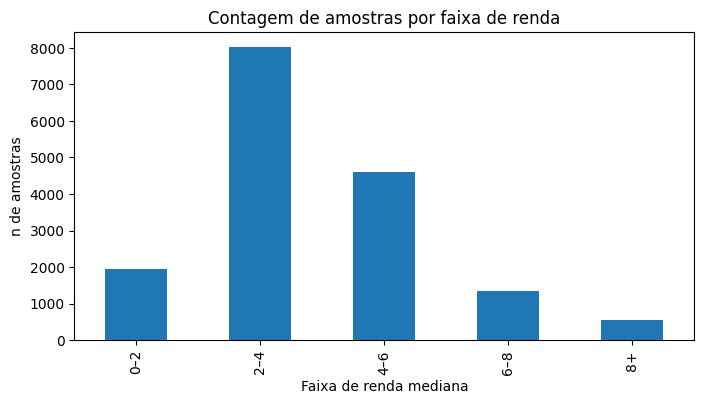

In [59]:
# 2) Barras: contagem por faixa (para ver desbalanceamento)
ax2 = grp.plot(kind="bar", x="MedInc_bin", y="n", legend=False, figsize=(8,4))
ax2.set_title("Contagem de amostras por faixa de renda")
ax2.set_xlabel("Faixa de renda mediana")
ax2.set_ylabel("n de amostras")
plt.show()

#### Interpretação — Barras por faixas de renda

- Observa-se uma **tendência de aumento** do valor médio das casas conforme a renda (`MedInc`) cresce — faixas mais altas tendem a ter `target` médio maior.  
- O gráfico de **contagem** mostra se existe **desbalanceamento** entre faixas (ex.: menos amostras em `8+`). Faixas com n pequeno pedem cautela na conclusão.  
- O padrão é consistente com o *scatter* `MedInc × target`: renda é um **forte preditor** do preço, mas há variação interna (outliers e o **teto em 5.0**).


In [49]:
# Salvar um CSV com o train set preparado para uso na próxima semana
train_out = Path("artifacts_semana03") / "train_set.csv"
train.to_csv(train_out, index=False)
print("Train salvo em:", train_out.resolve())

Train salvo em: C:\Users\Everton\Documents\IFSP\CMPINAM\1-Aulas\notebooks\artifacts_semana03\train_set.csv
